#### This notebook reproduces Figure S12 in "Exceeding Human Heat Tolerance: Global Projections for a Warming, Aging World" by Kong et al.

In [1]:
import xarray as xr
import numpy as np
import dask
import os
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.size": 16,        
    "axes.titlesize": 18,   
    "axes.labelsize": 18,   
    "xtick.labelsize": 16,  
    "ytick.labelsize": 16,  
    "legend.fontsize": 16,  
    "figure.titlesize": 20 
})

In [2]:
# directory to data; you might want to change it to your own directory
path='../data/'

young= pd.read_excel(path+'limits_young.xlsx',sheet_name=None)
old = pd.read_excel(path+'limits_old.xlsx',sheet_name=None)
middle = pd.read_excel(path+'limits_middle_aged.xlsx',sheet_name=None)


In [3]:
young = pd.read_excel('/home/kong97/coding/Larry/revision/plot/original_approach/young_mean.xlsx',sheet_name=None)
old = pd.read_excel('/home/kong97/coding/Larry/revision/plot/original_approach/old_mean.xlsx',sheet_name=None)
middle = pd.read_excel('/home/kong97/coding/Larry/revision/plot/original_approach/wider_middle_mean.xlsx',sheet_name=None)

In [4]:
cols = ['Age', 'Tdb', 'Pa', 'Tw']

# warm-humid trial
# select columns
df_young_34C  = young['34C'][cols]
df_middle_34C = middle['34C'][cols]
df_old_34C    = old['34C'][cols]
# concatenate row-wise
df_34C = pd.concat([df_young_34C, df_middle_34C, df_old_34C], axis=0, ignore_index=True)


# hot-dry trial
# select columns
df_young_12mmHg  = young['12mmHg'][cols][0:18]
df_middle_12mmHg = middle['12mmHg'][cols]
df_old_12mmHg    = old['12mmHg'][cols]

# concatenate row-wise
df_12mmHg = pd.concat([df_young_12mmHg, df_middle_12mmHg, df_old_12mmHg], axis=0, ignore_index=True)

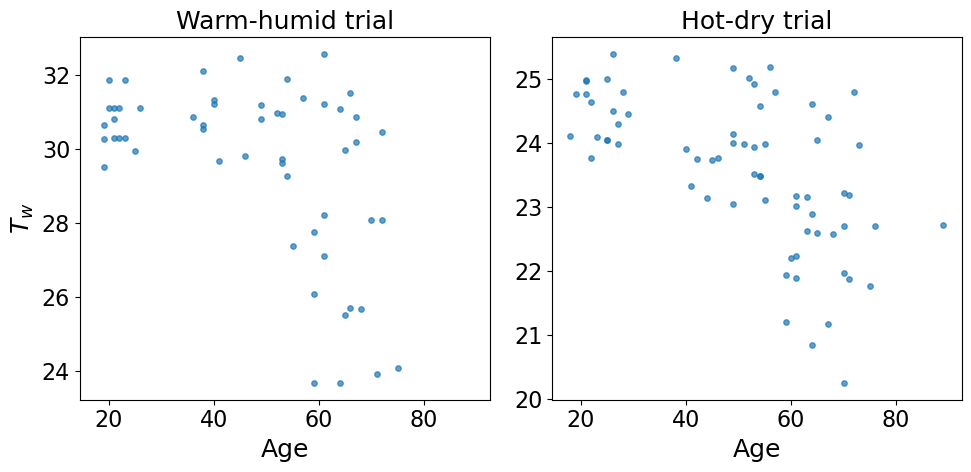

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True)

# left: warm-humid trial
axes[0].scatter(df_34C['Age'], df_34C['Tw'], s=15, alpha=0.7)
axes[0].set_title('Warm-humid trial')
axes[0].set_xlabel('Age')
axes[0].set_ylabel(r'$T_w$')


# right：hot-dry trial
axes[1].scatter(df_12mmHg['Age'], df_12mmHg['Tw'], s=15, alpha=0.7)
axes[1].set_title('Hot-dry trial')
axes[1].set_xlabel('Age')

plt.tight_layout()

**Fig. S12** Individual-level critical Tw thresholds across participant ages under a warm-humid trial (ambient temperature fixed at 34°C) and a hot-dry trial (vapor pressure fixed at 12 mmHg).